# Naive Bayes Classification - Mushroom Dataset

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


 Load and Explore the Dataset

In [2]:
df = pd.read_csv('mushroom.csv')
df.head(10)

,cap-shape,cap-color,bruises,odor,gill-color,stalk-shape,ring-type,spore-print-color,population,habitat,class
0,b,p,f,f,e,t,e,o,y,p,e
1,c,n,t,l,r,e,p,u,y,d,p
2,f,c,f,c,r,t,e,b,a,g,p
3,s,n,t,p,e,t,p,r,c,p,p
4,x,e,t,m,k,t,p,b,s,g,p
5,x,g,t,n,o,t,f,w,s,u,e
6,x,w,f,a,w,t,p,o,a,g,e
7,k,p,f,p,g,t,l,h,a,l,e
8,s,y,f,p,k,t,l,o,a,l,p
9,f,w,t,n,p,t,l,k,s,d,e


In [3]:
print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())

Shape: (500, 11)

Columns: ['cap-shape', 'cap-color', 'bruises', 'odor', 'gill-color', 'stalk-shape', 'ring-type', 'spore-print-color', 'population', 'habitat', 'class']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cap-shape          500 non-null    object
 1   cap-color          500 non-null    object
 2   bruises            500 non-null    object
 3   odor               500 non-null    object
 4   gill-color         500 non-null    object
 5   stalk-shape        500 non-null    object
 6   ring-type          500 non-null    object
 7   spore-print-color  500 non-null    object
 8   population         500 non-null    object
 9   habitat            500 non-null    object
 10  class              500 non-null    object
dtypes: object(11)
memory usage: 43.1+ KB


In [5]:
# all columns are object type (categorical) - thats why we cant use GaussianNB here
df.describe(include='all')

,cap-shape,cap-color,bruises,odor,gill-color,stalk-shape,ring-type,spore-print-color,population,habitat,class
count,500,500,500,500,500,500,500,500,500,500,500
unique,6,10,2,9,12,2,8,9,6,7,2
top,x,n,f,n,p,e,p,y,v,d,e
freq,179,63,280,125,50,267,155,67,89,85,260


In [6]:
# checking null values
print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
cap-shape            0
cap-color            0
bruises              0
odor                 0
gill-color           0
stalk-shape          0
ring-type            0
spore-print-color    0
population           0
habitat              0
class                0
dtype: int64


In [7]:
# class distribution
print("Class Distribution:")
print(df['class'].value_counts())
print()
print("e = Edible, p = Poisonous")

Class Distribution:
class
e    260
p    240
Name: count, dtype: int64

e = Edible, p = Poisonous


 Exploratory Data Analysis (EDA)

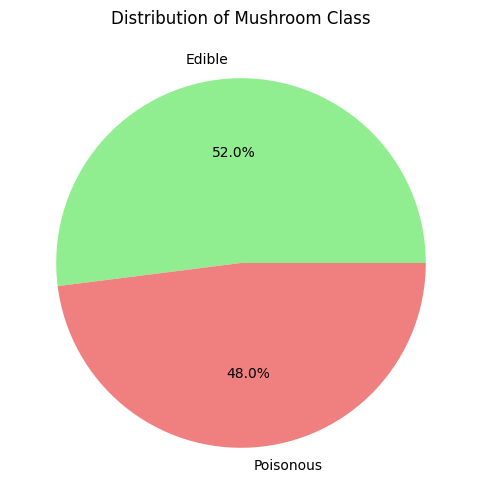

In [8]:
# pie chart of target class
plt.figure(figsize=(6,6))
df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['Edible', 'Poisonous'],
                                 colors=['lightgreen', 'lightcoral'])
plt.title('Distribution of Mushroom Class')
plt.ylabel('')
plt.show()

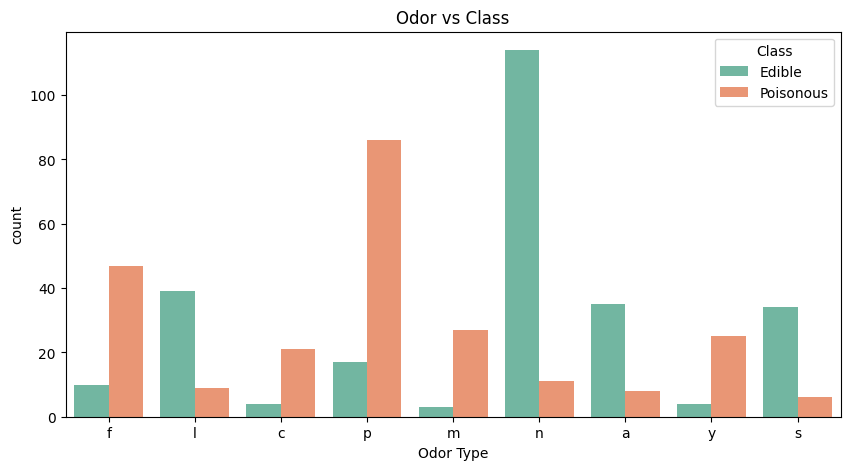

In [9]:

plt.figure(figsize=(10,5))
sns.countplot(x='odor', hue='class', data=df, palette='Set2')
plt.title('Odor vs Class')
plt.xlabel('Odor Type')
plt.legend(title='Class', labels=['Edible', 'Poisonous'])
plt.show()

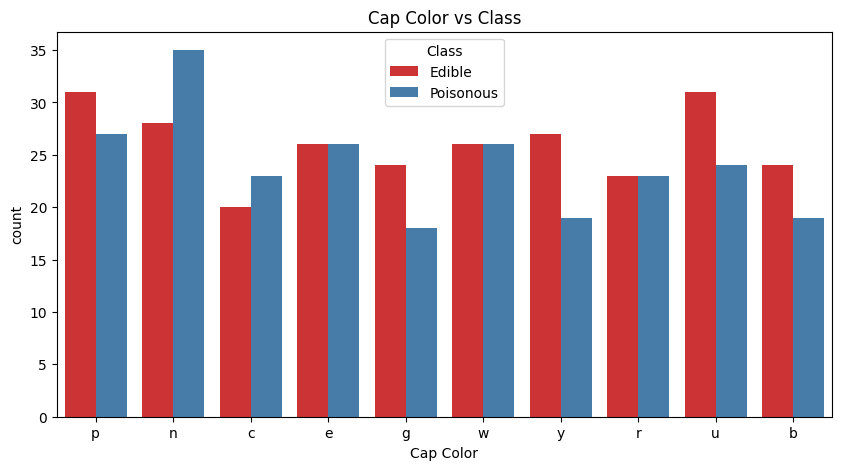

In [10]:
# cap color vs class
plt.figure(figsize=(10,5))
sns.countplot(x='cap-color', hue='class', data=df, palette='Set1')
plt.title('Cap Color vs Class')
plt.xlabel('Cap Color')
plt.legend(title='Class', labels=['Edible', 'Poisonous'])
plt.show()

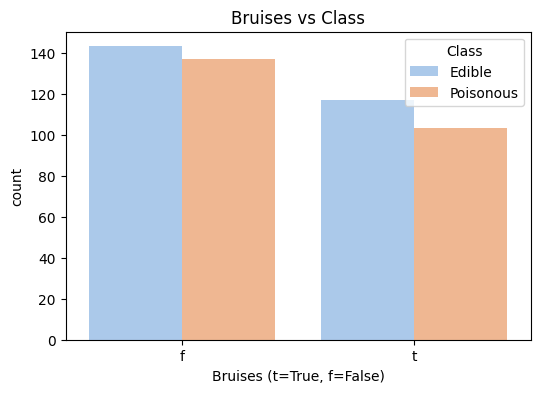

In [11]:
# bruises vs class
plt.figure(figsize=(6,4))
sns.countplot(x='bruises', hue='class', data=df, palette='pastel')
plt.title('Bruises vs Class')
plt.xlabel('Bruises (t=True, f=False)')
plt.legend(title='Class', labels=['Edible', 'Poisonous'])
plt.show()

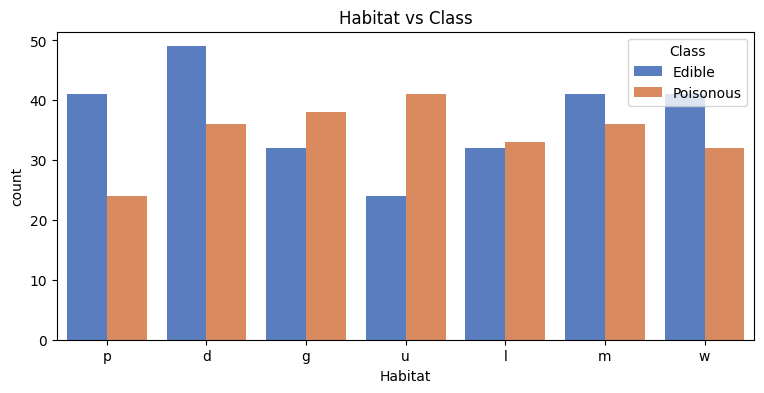

In [12]:
# habitat vs class
plt.figure(figsize=(9,4))
sns.countplot(x='habitat', hue='class', data=df, palette='muted')
plt.title('Habitat vs Class')
plt.xlabel('Habitat')
plt.legend(title='Class', labels=['Edible', 'Poisonous'])
plt.show()

In [13]:
# checking unique values in each column
print("Unique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} -> {df[col].unique()}")

Unique values per column:
  cap-shape: 6 -> ['b' 'c' 'f' 's' 'x' 'k']
  cap-color: 10 -> ['p' 'n' 'c' 'e' 'g' 'w' 'y' 'r' 'u' 'b']
  bruises: 2 -> ['f' 't']
  odor: 9 -> ['f' 'l' 'c' 'p' 'm' 'n' 'a' 'y' 's']
  gill-color: 12 -> ['e' 'r' 'k' 'o' 'w' 'g' 'p' 'n' 'y' 'b' 'u' 'h']
  stalk-shape: 2 -> ['t' 'e']
  ring-type: 8 -> ['e' 'p' 'f' 'l' 'b' 'n' 'r' 'z']
  spore-print-color: 9 -> ['o' 'u' 'b' 'r' 'w' 'h' 'k' 'y' 'n']
  population: 6 -> ['y' 'a' 'c' 's' 'n' 'v']
  habitat: 7 -> ['p' 'd' 'g' 'u' 'l' 'm' 'w']
  class: 2 -> ['e' 'p']


**Observation:** Odor seems to be a very strong indicator. Mushrooms with certain odors are almost always poisonous. Also mushrooms with bruises tend to be more edible.

 Data Preprocessing

In [14]:
# encoding target column
# e = edible = 0, p = poisonous = 1
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

print("Class encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

df.head()

Class encoding mapping:
  e -> 0
  p -> 1


,cap-shape,cap-color,bruises,odor,gill-color,stalk-shape,ring-type,spore-print-color,population,habitat,class
0,b,p,f,f,e,t,e,o,y,p,0
1,c,n,t,l,r,e,p,u,y,d,1
2,f,c,f,c,r,t,e,b,a,g,1
3,s,n,t,p,e,t,p,r,c,p,1
4,x,e,t,m,k,t,p,b,s,g,1


In [15]:
# separating features and target
X = df.drop('class', axis=1)
y = df['class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (500, 10)
Target shape: (500,)


In [16]:
# encoding all categorical features using OrdinalEncoder
oe = OrdinalEncoder()
X_encoded = oe.fit_transform(X)
print(X_encoded[:5])

[[0. 5. 0. 2. 1. 1. 1. 4. 5. 4.]
 [1. 4. 1. 3. 8. 0. 5. 6. 5. 0.]
 [2. 1. 0. 1. 8. 1. 1. 0. 0. 1.]
 [4. 4. 1. 6. 1. 1. 5. 5. 1. 4.]
 [5. 2. 1. 4. 4. 1. 5. 0. 3. 1.]]


In [17]:
# train test split 80-20
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (400, 10)
Testing size: (100, 10)


Applying Naive Bayes

In [18]:
# training the model
classifier = CategoricalNB()
classifier.fit(X_train, y_train)


,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [19]:
# predictions
y_pred = classifier.predict(X_test)

print("Predictions (first 10):", y_pred[:10])
print("Actual values (first 10):", y_test.values[:10])
print()

Predictions (first 10): [0 1 1 0 0 0 1 0 0 1]
Actual values (first 10): [0 1 1 0 0 1 1 0 0 1]



 Model Evaluation

In [20]:
# accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy of Naive Bayes Model: {acc * 100:.2f}%")

Accuracy of Naive Bayes Model: 81.00%


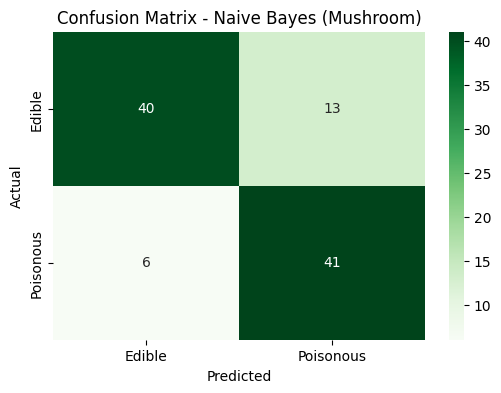

In [22]:
# confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title('Confusion Matrix - Naive Bayes (Mushroom)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [23]:
# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

Classification Report:
              precision    recall  f1-score   support

      Edible       0.87      0.75      0.81        53
   Poisonous       0.76      0.87      0.81        47

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.82      0.81      0.81       100



In [24]:
# actual vs predicted comparison
result_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
result_df['Actual_Label'] = result_df['Actual'].map({0:'Edible', 1:'Poisonous'})
result_df['Predicted_Label'] = result_df['Predicted'].map({0:'Edible', 1:'Poisonous'})
result_df['Correct'] = result_df['Actual'] == result_df['Predicted']

print(result_df.head(20))
print()
print(f"Correctly classified: {result_df['Correct'].sum()} / {len(result_df)}")

    Actual  Predicted Actual_Label Predicted_Label  Correct
0        0          0       Edible          Edible     True
1        1          1    Poisonous       Poisonous     True
2        1          1    Poisonous       Poisonous     True
3        0          0       Edible          Edible     True
4        0          0       Edible          Edible     True
5        1          0    Poisonous          Edible    False
6        1          1    Poisonous       Poisonous     True
7        0          0       Edible          Edible     True
8        0          0       Edible          Edible     True
9        1          1    Poisonous       Poisonous     True
10       0          0       Edible          Edible     True
11       0          0       Edible          Edible     True
12       1          1    Poisonous       Poisonous     True
13       0          0       Edible          Edible     True
14       1          1    Poisonous       Poisonous     True
15       0          0       Edible      